<a href="https://colab.research.google.com/github/Sucheta-afk/Graphs-for-Emotion-Recognition/blob/main/EEG_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os

base = '/content/drive/MyDrive/SEED-IV'

for folder in os.listdir(base):
    print(folder)
    sub = os.path.join(base, folder)
    if os.path.isdir(sub):
        for f in os.listdir(sub)[:5]:  # just first 5 files
            print('   ', f)
        print('   ...')

Mounted at /content/drive
eeg_feature_smooth
    2
    1
    3
   ...
Channel Order.xlsx
ReadMe.txt
eeg_raw_data
    2
    1
    3
   ...


In [2]:
!pip install mne -q

import mne
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 75.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.2.1 which is incompatible.


In [3]:
# Adjust path to match your actual folder structure
session1_path = '/content/drive/MyDrive/SEED-IV/eeg_feature_smooth/1/'

files = sorted(os.listdir(session1_path))
print(files)  # see all subject files in session 1

['10_20151014.mat', '11_20150916.mat', '12_20150725.mat', '13_20151115.mat', '14_20151205.mat', '15_20150508.mat', '1_20160518.mat', '2_20150915.mat', '3_20150919.mat', '4_20151111.mat', '5_20160406.mat', '6_20150507.mat', '7_20150715.mat', '8_20151103.mat', '9_20151028.mat']


Higher DE (Differential Entropy) → more brain activity / variability  
Lower DE → more stable / less active signal

In [4]:
mat = sio.loadmat(os.path.join(session1_path, files[0]))

for key in mat.keys():
    if not key.startswith('__'):  # skip metadata keys
        print(key, '-->', mat[key].shape)

de_movingAve1 --> (62, 42, 5)
de_LDS1 --> (62, 42, 5)
psd_movingAve1 --> (62, 42, 5)
psd_LDS1 --> (62, 42, 5)
de_movingAve2 --> (62, 23, 5)
de_LDS2 --> (62, 23, 5)
psd_movingAve2 --> (62, 23, 5)
psd_LDS2 --> (62, 23, 5)
de_movingAve3 --> (62, 49, 5)
de_LDS3 --> (62, 49, 5)
psd_movingAve3 --> (62, 49, 5)
psd_LDS3 --> (62, 49, 5)
de_movingAve4 --> (62, 32, 5)
de_LDS4 --> (62, 32, 5)
psd_movingAve4 --> (62, 32, 5)
psd_LDS4 --> (62, 32, 5)
de_movingAve5 --> (62, 22, 5)
de_LDS5 --> (62, 22, 5)
psd_movingAve5 --> (62, 22, 5)
psd_LDS5 --> (62, 22, 5)
de_movingAve6 --> (62, 40, 5)
de_LDS6 --> (62, 40, 5)
psd_movingAve6 --> (62, 40, 5)
psd_LDS6 --> (62, 40, 5)
de_movingAve7 --> (62, 38, 5)
de_LDS7 --> (62, 38, 5)
psd_movingAve7 --> (62, 38, 5)
psd_LDS7 --> (62, 38, 5)
de_movingAve8 --> (62, 52, 5)
de_LDS8 --> (62, 52, 5)
psd_movingAve8 --> (62, 52, 5)
psd_LDS8 --> (62, 52, 5)
de_movingAve9 --> (62, 36, 5)
de_LDS9 --> (62, 36, 5)
psd_movingAve9 --> (62, 36, 5)
psd_LDS9 --> (62, 36, 5)
de_movingA

bands - δ, θ, α, β, γ respectively

In [5]:
# Replace 'de_LDS1' with whatever key name you found above
trial_de = mat['de_LDS1']
print('Shape:', trial_de.shape)
print('First channel, first window, all 5 bands:', trial_de[0, 0, :])

Shape: (62, 42, 5)
First channel, first window, all 5 bands: [26.79152187 24.06211549 21.92761762 19.6974606  18.62685832]


In [6]:
def get_node_features(trial_de):
    # trial_de shape: (62, T, 5) → average over T → (62, 5)
    return trial_de.mean(axis=1)

H = get_node_features(trial_de)
print('Node feature matrix shape:', H.shape)  # should be (62, 5)

Node feature matrix shape: (62, 5)


eeg -> (62, N_timePoints)

In [7]:
raw_session1_path = '/content/drive/MyDrive/SEED-IV/eeg_raw_data/1/'

raw_files = sorted(os.listdir(raw_session1_path))
print(raw_files)

raw_mat = sio.loadmat(os.path.join(raw_session1_path, raw_files[0]))

for key in raw_mat.keys():
    if not key.startswith('__'):
        print(key, '-->', raw_mat[key].shape)

['10_20151014.mat', '11_20150916.mat', '12_20150725.mat', '13_20151115.mat', '14_20151205.mat', '15_20150508.mat', '1_20160518.mat', '2_20150915.mat', '3_20150919.mat', '4_20151111.mat', '5_20160406.mat', '6_20150507.mat', '7_20150715.mat', '8_20151103.mat', '9_20151028.mat']
tyc_eeg1 --> (62, 33601)
tyc_eeg2 --> (62, 19001)
tyc_eeg3 --> (62, 39801)
tyc_eeg4 --> (62, 26001)
tyc_eeg5 --> (62, 17601)
tyc_eeg6 --> (62, 32401)
tyc_eeg7 --> (62, 30601)
tyc_eeg8 --> (62, 41801)
tyc_eeg9 --> (62, 29001)
tyc_eeg10 --> (62, 33801)
tyc_eeg11 --> (62, 10001)
tyc_eeg12 --> (62, 22001)
tyc_eeg13 --> (62, 43401)
tyc_eeg14 --> (62, 33801)
tyc_eeg15 --> (62, 51801)
tyc_eeg16 --> (62, 28201)
tyc_eeg17 --> (62, 13601)
tyc_eeg18 --> (62, 35801)
tyc_eeg19 --> (62, 28001)
tyc_eeg20 --> (62, 9601)
tyc_eeg21 --> (62, 22401)
tyc_eeg22 --> (62, 22401)
tyc_eeg23 --> (62, 35001)
tyc_eeg24 --> (62, 27401)


Raw EEG shape: (62, 33601)


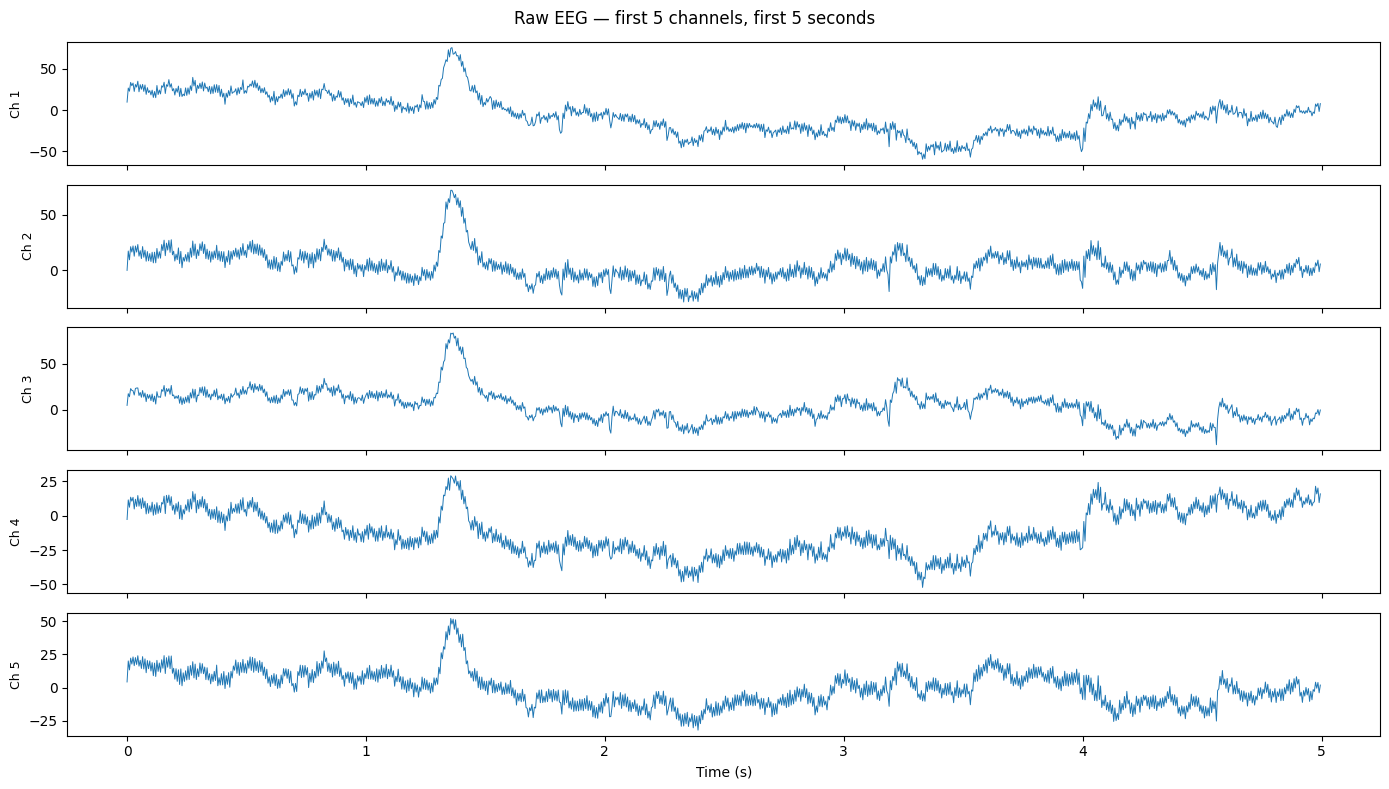

In [9]:
# Load one raw trial
raw_eeg = raw_mat['tyc_eeg1']  # replace key name with what you found
print('Raw EEG shape:', raw_eeg.shape)  # expect (62, N_samples)

sfreq = 200  # sampling rate in Hz (confirm from ReadMe)
n_channels = 62
times = np.arange(raw_eeg.shape[1]) / sfreq  # time axis in seconds

# Plot first 5 channels, first 5 seconds
fig, axes = plt.subplots(5, 1, figsize=(14, 8), sharex=True)
for i in range(5):
    axes[i].plot(times[:5*sfreq], raw_eeg[i, :5*sfreq], linewidth=0.7)
    axes[i].set_ylabel(f'Ch {i+1}', fontsize=9)
axes[-1].set_xlabel('Time (s)')
plt.suptitle('Raw EEG — first 5 channels, first 5 seconds')
plt.tight_layout()
plt.show()

#### Final Day1 Report:  
**Key names in feature_smooth .mat files:**  
*   de_movingAve1 --> (62, 42, 5)  
*   de_LDS1 --> (62, 42, 5)  
*   psd_movingAve1 --> (62, 42, 5)
*   psd_LDS1 --> (62, 42, 5)   

**Key names in raw .mat files:**  
*   tyc_eeg1 --> (62, 33601)
*   tyc_eeg2 --> (62, 19001)


**Shape of raw EEG array for one trial:** (62, 33601)  
**Number of trials per subject per session:** 15  
**Sampling rate:** 200 Hz  
**Shape of DE array for one trial:**  
*   Shape: (62, 42, 5)
*   First channel, first window, all 5 bands: [26.79152187, 24.06211549, 21.92761762, 19.6974606, 18.62685832]    

# Band-pass filtering + PLV computation

In [11]:
BANDS = {
    'delta': (1, 4),
    'theta': (4, 8),
    'alpha': (8, 14),
    'beta':  (14, 31),
    'gamma': (31, 50)
}

In [12]:
from scipy.signal import butter, filtfilt

def bandpass_filter(eeg, lowcut, highcut, fs=200, order=4):
    """
    eeg   : shape (n_channels, n_samples)
    returns filtered eeg of same shape
    """
    nyq = fs / 2
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    # apply filter to each channel independently
    filtered = filtfilt(b, a, eeg, axis=1)
    return filtered

In [13]:
alpha_eeg = bandpass_filter(raw_eeg, *BANDS['alpha'])
print('Filtered shape:', alpha_eeg.shape)  # should still be (62, N_samples)

Filtered shape: (62, 33601)


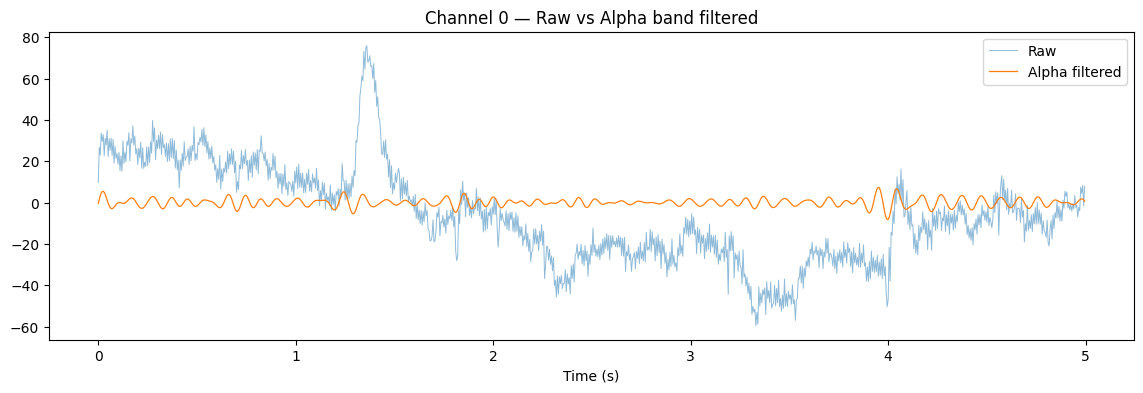

In [14]:
ch = 0  # first channel
t = np.arange(raw_eeg.shape[1]) / sfreq

plt.figure(figsize=(14, 4))
plt.plot(t[:5*sfreq], raw_eeg[ch, :5*sfreq], alpha=0.5, label='Raw', linewidth=0.7)
plt.plot(t[:5*sfreq], alpha_eeg[ch, :5*sfreq], label='Alpha filtered', linewidth=0.9)
plt.xlabel('Time (s)')
plt.legend()
plt.title('Channel 0 — Raw vs Alpha band filtered')
plt.show()